In [1]:
pip install pandas numpy matplotlib scikit-learn openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("study_productivity_1000rows.xlsx")

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Session_ID                  1000 non-null   int64  
 1   Study_Time                  1000 non-null   float64
 2   Productivity_Score          1000 non-null   float64
 3   Time_of_Day                 1000 non-null   object 
 4   Breaks_Taken                1000 non-null   int64  
 5   Distractions                1000 non-null   object 
 6   Subject_Type                1000 non-null   object 
 7   Environment                 1000 non-null   object 
 8   Mood_Level                  1000 non-null   int64  
 9   Sleep_Hours_Previous_Night  1000 non-null   int64  
 10  Device_Usage                1000 non-null   int64  
 11  Music_Played                1000 non-null   object 
 12  Weather                     1000 non-null   object 
dtypes: float64(2), int64(5), object(6)

,Session_ID,Study_Time,Productivity_Score,Breaks_Taken,Mood_Level,Sleep_Hours_Previous_Night,Device_Usage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.961600,4.196500,2.493000,6.460000,5.976000,29.993000
std,288.819436,1.169758,1.728214,1.701425,2.303412,1.418251,17.118294
min,1.000000,1.000000,0.000000,0.000000,3.000000,4.000000,0.000000
25%,250.750000,1.900000,3.000000,1.000000,4.000000,5.000000,15.000000
50%,500.500000,3.000000,4.200000,3.000000,6.000000,6.000000,30.000000
75%,750.250000,4.000000,5.400000,4.000000,8.250000,7.000000,44.250000
max,1000.000000,5.000000,9.200000,5.000000,10.000000,8.000000,60.000000


In [5]:
df.isnull().sum()

Session_ID                    0
Study_Time                    0
Productivity_Score            0
Time_of_Day                   0
Breaks_Taken                  0
Distractions                  0
Subject_Type                  0
Environment                   0
Mood_Level                    0
Sleep_Hours_Previous_Night    0
Device_Usage                  0
Music_Played                  0
Weather                       0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [8]:
X = df_encoded.drop("Productivity_Score", axis=1)
y = df_encoded["Productivity_Score"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.7462087184014695
R2 Score: 0.7008165430234699


In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_
})

print(importance.sort_values(by="Importance", ascending=False))

                       Feature  Importance
1                   Study_Time    0.774349
7          Time_of_Day_Morning    0.698415
4   Sleep_Hours_Previous_Night    0.526411
3                   Mood_Level    0.291264
12         Subject_Type_Theory    0.247297
10         Subject_Type_Design    0.211919
11           Subject_Type_Math    0.172410
6          Time_of_Day_Evening    0.101911
16               Weather_Rainy    0.072953
14         Environment_Library    0.062785
0                   Session_ID    0.000077
13            Environment_Home   -0.003820
17               Weather_Sunny   -0.008061
15            Music_Played_Yes   -0.014222
5                 Device_Usage   -0.014267
2                 Breaks_Taken   -0.049234
8            Time_of_Day_Night   -0.329371
9             Distractions_Yes   -1.480994


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("RF R2:", r2_score(y_test, rf.predict(X_test)))

RF R2: 0.6087869980606626


In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7008165430234699


In [19]:
print("Accuracy:", r2 * 100, "%")

Accuracy: 70.08165430234699 %


In [20]:
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
1,Study_Time,0.774349
7,Time_of_Day_Morning,0.698415
4,Sleep_Hours_Previous_Night,0.526411
3,Mood_Level,0.291264
12,Subject_Type_Theory,0.247297
10,Subject_Type_Design,0.211919
11,Subject_Type_Math,0.172410
6,Time_of_Day_Evening,0.101911
16,Weather_Rainy,0.072953
14,Environment_Library,0.062785


In [21]:
sample = X_test.iloc[0].values.reshape(1, -1)
print("Predicted:", model.predict(sample))
print("Actual:", y_test.iloc[0])

Predicted: [3.86419485]
Actual: 3.2


C:\Users\Ankitha K\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
print("Linear:", r2_score(y_test, y_pred))
print("RF:", r2_score(y_test, rf.predict(X_test)))

NameError: name 'r2_score' is not defined

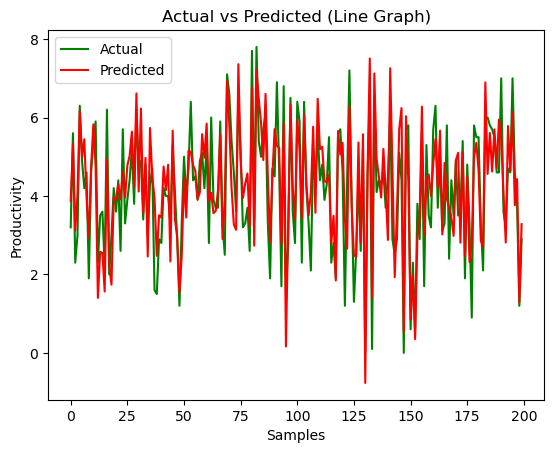

In [23]:
plt.plot(y_test.values, color='green', label='Actual')
plt.plot(y_pred, color='red', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted (Line Graph)")
plt.xlabel("Samples")
plt.ylabel("Productivity")
plt.show()

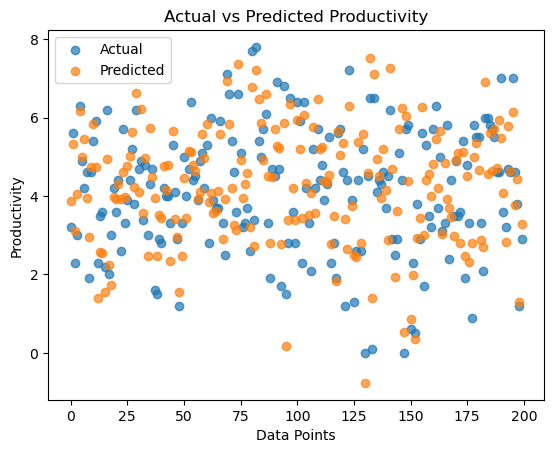

In [28]:
import matplotlib.pyplot as plt

plt.figure()

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)

# Predicted values (red)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)

plt.xlabel("Data Points")
plt.ylabel("Productivity")
plt.title("Actual vs Predicted Productivity")

plt.legend()
plt.show()

Dataset Preview:


,Session_ID,Study_Time,Productivity_Score,Time_of_Day,Breaks_Taken,Distractions
0,1,1.5,9,2,2,0
1,2,3.0,6,0,1,1
2,3,2.5,8,1,3,0
3,4,4.0,5,3,0,1
4,5,2.0,7,2,2,0


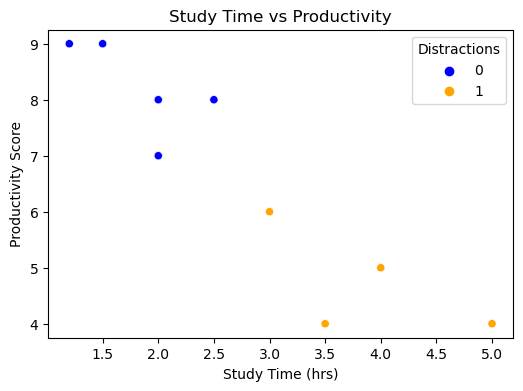

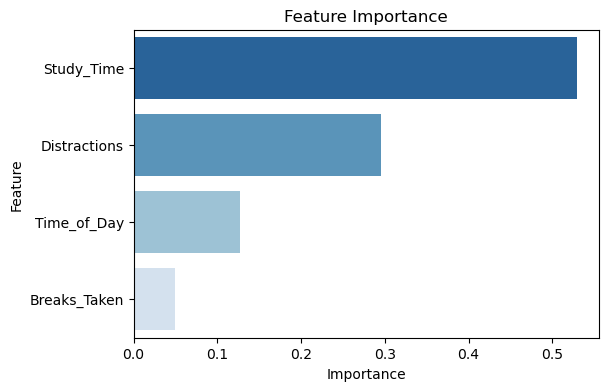

Predicted Productivity Score: 7.67 / 10


In [30]:
# Install required libraries if not already installed
# !pip install pandas seaborn matplotlib scikit-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 1. Create or Load Dataset
# -----------------------------
data = pd.DataFrame({
    "Session_ID": [1,2,3,4,5,6,7,8,9],
    "Study_Time":[1.5,3.0,2.5,4.0,2.0,3.5,2.0,5.0,1.2],
    "Productivity_Score":[9,6,8,5,7,4,8,4,9],
    "Time_of_Day":["Morning","Afternoon","Evening","Night","Morning","Afternoon","Evening","Night","Morning"],
    "Breaks_Taken":[2,1,3,0,2,2,1,1,3],
    "Distractions":["No","Yes","No","Yes","No","Yes","No","Yes","No"]
})

# Encode categorical features
data["Time_of_Day"] = data["Time_of_Day"].astype("category").cat.codes
data["Distractions"] = data["Distractions"].map({"No":0,"Yes":1})

# -----------------------------
# 2. Dataset Preview
# -----------------------------
print("Dataset Preview:")
display(data.head())

# -----------------------------
# 3. Scatter Plot
# -----------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x="Study_Time", y="Productivity_Score", hue="Distractions", data=data, palette=["blue","orange"])
plt.title("Study Time vs Productivity")
plt.xlabel("Study Time (hrs)")
plt.ylabel("Productivity Score")
plt.show()

# -----------------------------
# 4. Train Model
# -----------------------------
X = data[["Study_Time","Time_of_Day","Breaks_Taken","Distractions"]]
y = data["Productivity_Score"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X,y)

# -----------------------------
# 5. Feature Importance
# -----------------------------
importances = model.feature_importances_
feat_imp = pd.DataFrame({"Feature":X.columns,"Importance":importances}).sort_values(by="Importance",ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="Blues_r")
plt.title("Feature Importance")
plt.show()

# -----------------------------
# 6. Predict New Study Session
# -----------------------------
new_session = pd.DataFrame({
    "Study_Time":[2.0],
    "Time_of_Day":[0],  # Morning = 0
    "Breaks_Taken":[2],
    "Distractions":[0]  # No distractions
})

prediction = model.predict(new_session)[0]
print(f"Predicted Productivity Score: {prediction:.2f} / 10")

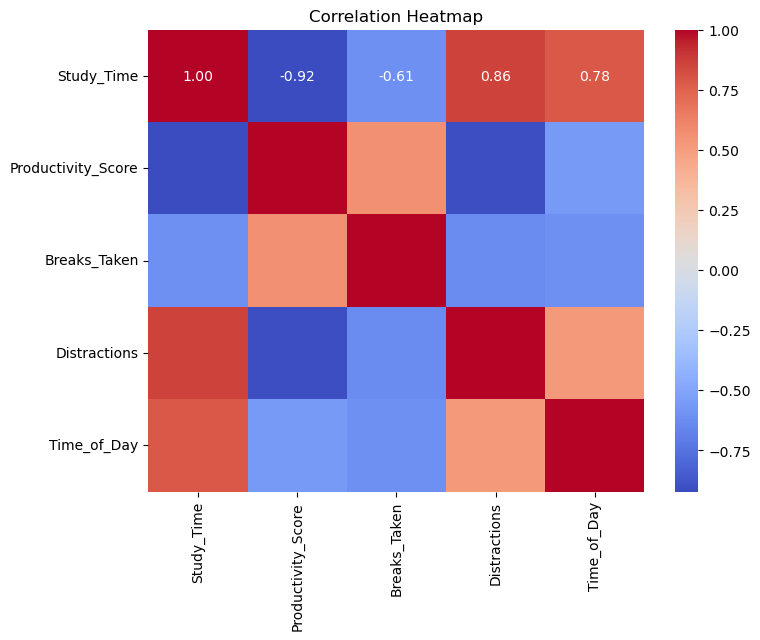

C:\Users\Ankitha K\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ankitha K\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ankitha K\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Ankitha K\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

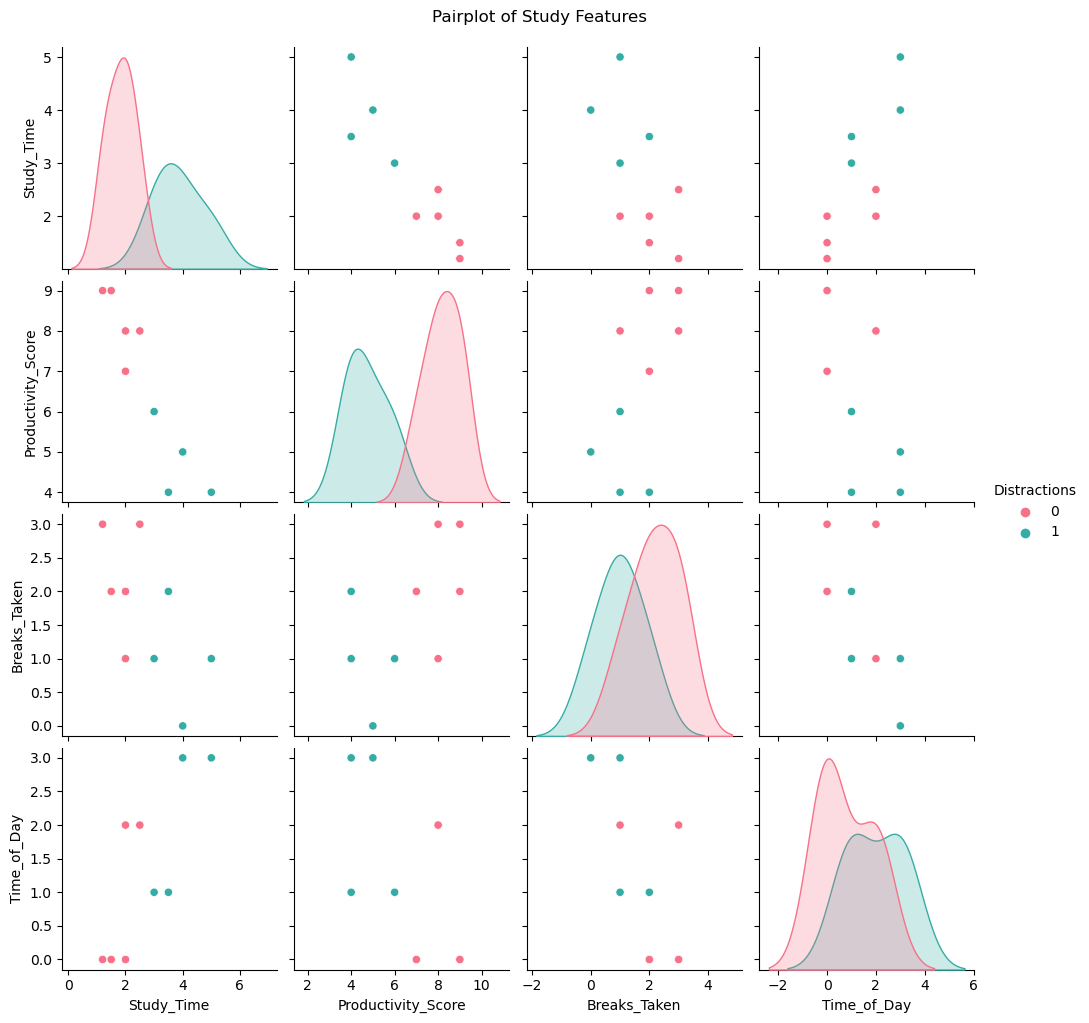

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataset
data = pd.DataFrame({
    "Study_Time":[1.5,3.0,2.5,4.0,2.0,3.5,2.0,5.0,1.2],
    "Productivity_Score":[9,6,8,5,7,4,8,4,9],
    "Breaks_Taken":[2,1,3,0,2,2,1,1,3],
    "Distractions":[0,1,0,1,0,1,0,1,0],
    "Time_of_Day":[0,1,2,3,0,1,2,3,0] # Morning=0, Afternoon=1, Evening=2, Night=3
})

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(data, hue="Distractions", palette="husl")
plt.suptitle("Pairplot of Study Features", y=1.02)
plt.show()

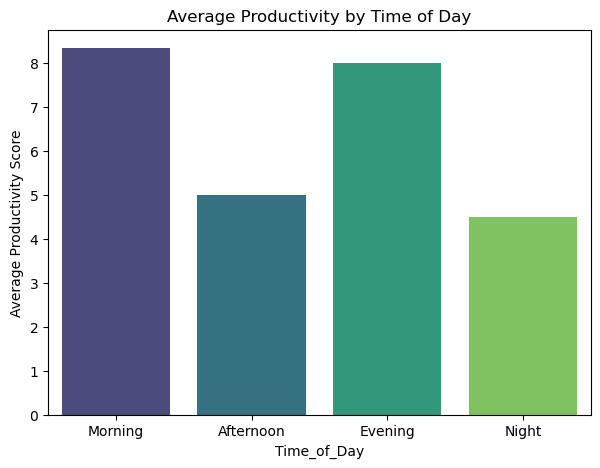

In [32]:
import seaborn as sns

# Group by time of day
avg_prod = data.groupby("Time_of_Day")["Productivity_Score"].mean().reset_index()

# Map numeric codes to labels
labels = {0:"Morning",1:"Afternoon",2:"Evening",3:"Night"}
avg_prod["Time_of_Day"] = avg_prod["Time_of_Day"].map(labels)

plt.figure(figsize=(7,5))
sns.barplot(x="Time_of_Day", y="Productivity_Score", data=avg_prod, palette="viridis")
plt.title("Average Productivity by Time of Day")
plt.ylabel("Average Productivity Score")
plt.show()

In [47]:
def give_suggestions(input_data):
    suggestions = []
    
    if input_data['study_time'] < 5:
        suggestions.append("Increase study time to at least 5-6 hours")
        
    if input_data['sleep_hours'] < 6:
        suggestions.append("Improve sleep to at least 7 hours")
        
    if input_data['distraction'] == "Yes":
        suggestions.append("Reduce distractions (avoid phone/social media)")
        
    if input_data['breaks_taken'] < 2:
        suggestions.append("Take short breaks to improve focus")
        
    if input_data['device_usage'] == "High":
        suggestions.append("Limit device usage during study time")
        
    return suggestions

In [48]:
student = {
    'study_time': 3,
    'sleep_hours': 5,
    'distraction': "Yes",
    'breaks_taken': 1,
    'device_usage': "High"
}

print(give_suggestions(student))

['Increase study time to at least 5-6 hours', 'Improve sleep to at least 7 hours', 'Reduce distractions (avoid phone/social media)', 'Take short breaks to improve focus', 'Limit device usage during study time']
